<a href="https://colab.research.google.com/github/davidromero2534582021/Parcial4_David_Romero_2534582021/blob/main/Parcial_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
#Cargar el archivo CSV correctamente en Python
ruta_archivo = 'https://raw.githubusercontent.com/davidromero2534582021/Parcial4_David_Romero_2534582021/refs/heads/main/clave_G_asociacion.csv'
df = pd.read_csv(ruta_archivo)

In [4]:
#Mostrar las primeras filas del dataset y explicar su estructura.
df.head()

,transaccion_id,cliente_id,fecha,categoria,item,cantidad,canal
0,G-T0001,G-C0072,2026-02-20,Construccion,Arena,1,Tienda
1,G-T0001,G-C0072,2026-02-20,Herramientas,Destornillador,1,Tienda
2,G-T0001,G-C0072,2026-02-20,Pintura,Lija,3,Tienda
3,G-T0002,G-C0057,2026-01-26,Electricidad,Cable,2,App
4,G-T0002,G-C0057,2026-01-26,Electricidad,Interruptor,1,App


In [16]:
print("=== DIAGNÓSTICO DE CALIDAD ===")
print(f"\nValores nulos por columna:")
print(df.isnull().sum())

print(f"\n Filas duplicadas: {df.duplicated().sum()}")

print(f"\n Tipos de datos:")
print(df.dtypes)

=== DIAGNÓSTICO DE CALIDAD ===

Valores nulos por columna:
transaccion_id    0
cliente_id        0
fecha             0
categoria         0
item              0
cantidad          0
canal             0
dtype: int64

 Filas duplicadas: 0

 Tipos de datos:
transaccion_id    object
cliente_id        object
fecha             object
categoria         object
item              object
cantidad           int64
canal             object
dtype: object


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [17]:
# Acción correctiva
df_limpio = df.dropna(subset=['canal'])  # Eliminar 1 fila con canal nulo
df_limpio = df_limpio.drop_duplicates()   # Eliminar duplicados

print(f"\n✅ Después de limpieza: {len(df_limpio)} filas (original: {len(df)})")


✅ Después de limpieza: 620 filas (original: 620)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [18]:

# CELDA 4: TRANSFORMACIÓN A FORMATO BINARIO
# Convertimos datos largos a matriz items × transacciones
# El algoritmo Apriori requiere formato one-hot encoded

# Crear matriz de transacciones
basket = df_limpio.groupby(['transaccion_id', 'item'])['cantidad'].sum().unstack().fillna(0)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [19]:
# Convertir a binario (1 si compró, 0 si no)
basket_binario = basket.applymap(lambda x: 1 if x > 0 else 0)

print("=== FORMATO PARA APRIORI ===")
print(f"Transacciones: {basket_binario.shape[0]}")
print(f"Productos únicos: {basket_binario.shape[1]}")
print(f"Densidad de compras: {(basket_binario.sum().sum() / (basket_binario.shape[0] * basket_binario.shape[1]) * 100):.2f}%")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

=== FORMATO PARA APRIORI ===
Transacciones: 195
Productos únicos: 20
Densidad de compras: 15.90%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [20]:
# Visualización de los productos más comunes
top_productos = basket_binario.sum().sort_values(ascending=False).head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

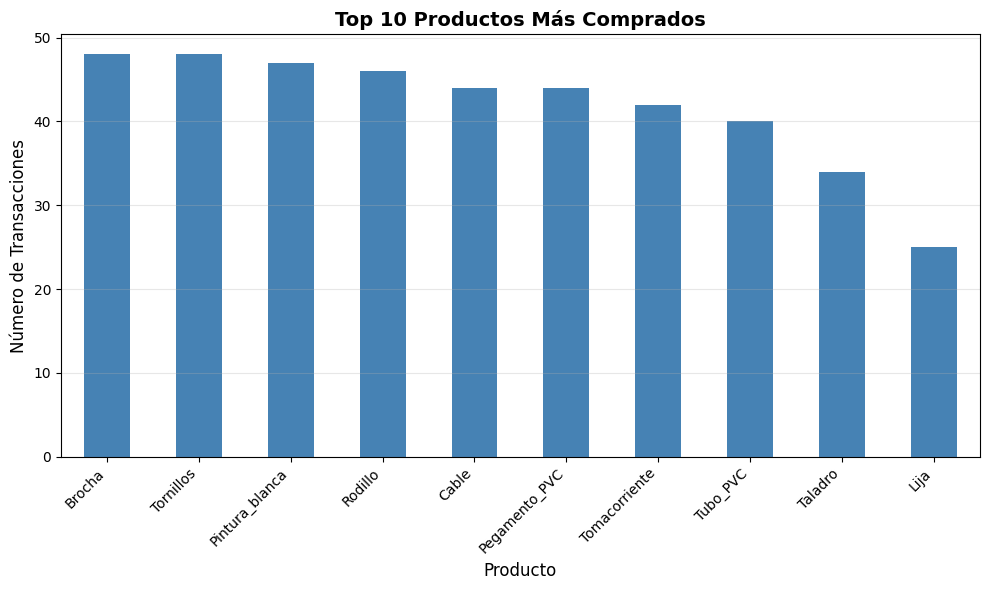

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [21]:
# GRÁFICO 1: Productos más comprados
plt.figure(figsize=(10, 6))
top_productos.plot(kind='bar', color='steelblue')
plt.title('Top 10 Productos Más Comprados', fontsize=14, fontweight='bold')
plt.xlabel('Producto', fontsize=12)
plt.ylabel('Número de Transacciones', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('top_productos.png', dpi=100)  # Para captura
plt.show()

In [22]:

# CELDA 5: APLICACIÓN DEL ALGORITMO APRIORI
#  Buscamos conjuntos de items que aparecen juntos frecuentemente
#  Soporte mide frecuencia, confianza mide fiabilidad

# Ajustar min_support según densidad (15.9% es alta → usar 0.05)
min_support_val = 0.05  # Aparece en al menos 5% de transacciones

itemsets_frecuentes = apriori(basket_binario,
                              min_support=min_support_val,
                              use_colnames=True)

print(f"=== ITEMSETS FRECUENTES (min_support={min_support_val}) ===")
print(f"Itemsets encontrados: {len(itemsets_frecuentes)}")

if len(itemsets_frecuentes) > 0:
    print(f"\nTop 5 itemsets por soporte:")
    top_itemsets = itemsets_frecuentes.nlargest(5, 'support')
    for idx, row in top_itemsets.iterrows():
        items = ', '.join(list(row['itemsets']))
        print(f"  • {items}: soporte = {row['support']:.4f} ({row['support']*100:.2f}%)")
else:
    print("⚠️ No hay itemsets con soporte 0.05, reduciendo a 0.03...")
    itemsets_frecuentes = apriori(basket_binario, min_support=0.03, use_colnames=True)
    print(f"Itemsets encontrados: {len(itemsets_frecuentes)}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

=== ITEMSETS FRECUENTES (min_support=0.05) ===
Itemsets encontrados: 35

Top 5 itemsets por soporte:
  • Brocha: soporte = 0.2462 (24.62%)
  • Tornillos: soporte = 0.2462 (24.62%)
  • Pintura_blanca: soporte = 0.2410 (24.10%)
  • Rodillo: soporte = 0.2359 (23.59%)
  • Cable: soporte = 0.2256 (22.56%)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [23]:
# CELDA 6: GENERACIÓN DE REGLAS DE ASOCIACIÓN
# Explicación: Creamos reglas con métricas de evaluación
# - Support: frecuencia de la combinación
# - Confidence: probabilidad condicional
# - Lift: qué tan superior es la regla al azar (lift>1 es útil)

reglas = association_rules(itemsets_frecuentes,
                          metric="lift",
                          min_threshold=1.0)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [24]:
# Ordenar por lift (las más relevantes)
reglas_ordenadas = reglas.sort_values('lift', ascending=False)

print(f"=== REGLAS GENERADAS ===")
print(f"Total de reglas: {len(reglas_ordenadas)}")
print(f"\nTop 10 reglas por Lift:")
print(reglas_ordenadas[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

=== REGLAS GENERADAS ===
Total de reglas: 30

Top 10 reglas por Lift:
                  antecedents                consequents   support  \
25          (Rodillo, Brocha)           (Pintura_blanca)  0.092308   
28           (Pintura_blanca)          (Rodillo, Brocha)  0.092308   
26   (Pintura_blanca, Brocha)                  (Rodillo)  0.092308   
27                  (Rodillo)   (Pintura_blanca, Brocha)  0.092308   
24  (Rodillo, Pintura_blanca)                   (Brocha)  0.092308   
29                   (Brocha)  (Rodillo, Pintura_blanca)  0.092308   
15                 (Tubo_PVC)            (Pegamento_PVC)  0.128205   
14            (Pegamento_PVC)                 (Tubo_PVC)  0.128205   
10            (Tomacorriente)                    (Cable)  0.112821   
11                    (Cable)            (Tomacorriente)  0.112821   

    confidence      lift  
25    0.900000  3.734043  
28    0.382979  3.734043  
26    0.818182  3.468379  
27    0.391304  3.468379  
24    0.750000  3.046875

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

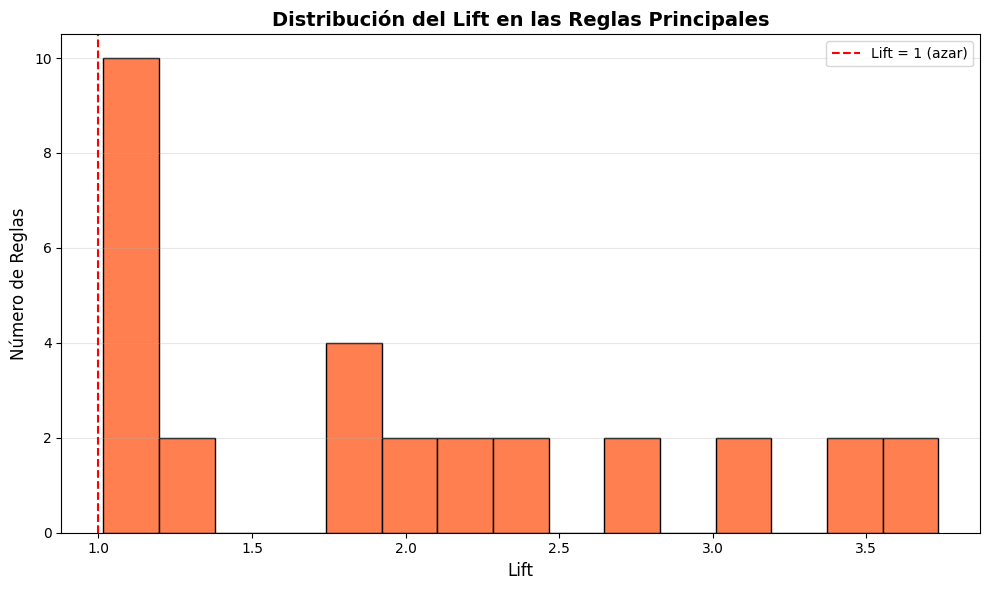

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [25]:
# GRÁFICO 2: Distribución de Lift en las reglas
plt.figure(figsize=(10, 6))
plt.hist(reglas_ordenadas['lift'].head(50), bins=15, color='coral', edgecolor='black')
plt.title('Distribución del Lift en las Reglas Principales', fontsize=14, fontweight='bold')
plt.xlabel('Lift', fontsize=12)
plt.ylabel('Número de Reglas', fontsize=12)
plt.axvline(x=1.0, color='red', linestyle='--', label='Lift = 1 (azar)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('distribucion_lift.png', dpi=100)
plt.show()

In [27]:
#CELDA 7: INTERPRETACIÓN DE 5 REGLAS CLAVE
# ============================================
# Explicación: Traducimos resultados técnicos a lenguaje comercial

print("=== INTERPRETACIÓN COMERCIAL DE REGLAS ===")
print("\n" + "="*80)

# Seleccionar top 5 reglas con lift > 1.5 (significativas)
top_5_reglas = reglas_ordenadas[reglas_ordenadas['lift'] > 1.5].head(5)

for i, (idx, regla) in enumerate(top_5_reglas.iterrows(), 1):
    antecedentes = ', '.join(list(regla['antecedents']))
    consecuentes = ', '.join(list(regla['consequents']))

    print(f"\n📌 REGLA {i}:")
    print(f"   SI el cliente compra: {antecedentes}")
    print(f"   ENTONCES también compra: {consecuentes}")
    print(f"\n   📊 Métricas:")
    print(f"      • Soporte: {regla['support']*100:.2f}% (aparece en {regla['support']*100:.1f}% de transacciones)")
    print(f"      • Confianza: {regla['confidence']*100:.2f}% (probabilidad de comprar {consecuentes})")
    print(f"      • Lift: {regla['lift']:.2f} (venta {'{:.0f}'.format(regla['lift']*100)}% más probable que al azar)")

    print(f"\n   💡 Interpretación comercial:")
    if regla['lift'] > 2:
        print(f"      → Asociación MUY FUERTE. Los clientes que compran {antecedentes}")
        print(f"        tienen {regla['lift']:.1f} veces más probabilidad de comprar {consecuentes}.")
    elif regla['lift'] > 1.5:
        print(f"      → Asociación MODERADA. Existe una relación comercial relevante.")
    else:
        print(f"      → Asociación DÉBIL, pero puede tener valor estacional.")

    print("-"*80)

# Guardar reglas interpretadas
top_5_reglas.to_csv('reglas_top5_interpretadas.csv', index=False)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

=== INTERPRETACIÓN COMERCIAL DE REGLAS ===


📌 REGLA 1:
   SI el cliente compra: Rodillo, Brocha
   ENTONCES también compra: Pintura_blanca

   📊 Métricas:
      • Soporte: 9.23% (aparece en 9.2% de transacciones)
      • Confianza: 90.00% (probabilidad de comprar Pintura_blanca)
      • Lift: 3.73 (venta 373% más probable que al azar)

   💡 Interpretación comercial:
      → Asociación MUY FUERTE. Los clientes que compran Rodillo, Brocha
        tienen 3.7 veces más probabilidad de comprar Pintura_blanca.
--------------------------------------------------------------------------------

📌 REGLA 2:
   SI el cliente compra: Pintura_blanca
   ENTONCES también compra: Rodillo, Brocha

   📊 Métricas:
      • Soporte: 9.23% (aparece en 9.2% de transacciones)
      • Confianza: 38.30% (probabilidad de comprar Rodillo, Brocha)
      • Lift: 3.73 (venta 373% más probable que al azar)

   💡 Interpretación comercial:
      → Asociación MUY FUERTE. Los clientes que compran Pintura_blanca
        ti

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [28]:
# ============================================
# CELDA 8: RECOMENDACIONES COMERCIALES
# ============================================
# Explicación: Propuestas accionables para el negocio basadas en las reglas

print("\n=== RECOMENDACIONES COMERCIALES ESTRATÉGICAS ===\n")

recomendaciones = [
    {
        "estrategia": "🎯 Venta Cruzada (Cross-Selling)",
        "accion": "Implementar sugerencias automáticas 'Quienes compraron X también compraron Y'",
        "basado_en": "Reglas con lift > 2.0",
        "ejemplo": "Al agregar producto A al carrito, mostrar producto B con descuento del 10%"
    },
    {
        "estrategia": "📦 Paquetes Promocionales (Bundling)",
        "accion": "Crear combos fijos con los productos más asociados",
        "basado_en": "Reglas con soporte > 0.05 y confianza > 0.6",
        "ejemplo": "Pack 'Cena completa' con productos que aparecen juntos frecuentemente"
    },
    {
        "estrategia": "📍 Optimización de Layout en Tienda",
        "accion": "Ubicar productos asociados cerca físicamente",
        "basado_en": "Reglas con lift > 1.8",
        "ejemplo": "Colocar productos complementarios en góndolas adyacentes o pasillos"
    },
    {
        "estrategia": "📧 Campañas de Email Marketing",
        "accion": "Segmentar clientes por productos comprados y ofrecer relacionados",
        "basado_en": "Reglas con confianza > 0.7",
        "ejemplo": "Enviar oferta de producto Y a quienes compraron X en últimos 30 días"
    },
    {
        "estrategia": "🏷️ Descuentos Condicionales",
        "accion": "Ofrecer descuento en producto consecuente al comprar antecedente",
        "basado_en": "Reglas con lift > 1.5 pero confianza moderada",
        "ejemplo": "15% de descuento en producto Y al presentar ticket de compra de X"
    }
]

for i, rec in enumerate(recomendaciones, 1):
    print(f"{rec['estrategia']}")
    print(f"   📌 Acción: {rec['accion']}")
    print(f"   📊 Basado en: {rec['basado_en']}")
    print(f"   💡 Ejemplo: {rec['ejemplo']}\n")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


=== RECOMENDACIONES COMERCIALES ESTRATÉGICAS ===

🎯 Venta Cruzada (Cross-Selling)
   📌 Acción: Implementar sugerencias automáticas 'Quienes compraron X también compraron Y'
   📊 Basado en: Reglas con lift > 2.0
   💡 Ejemplo: Al agregar producto A al carrito, mostrar producto B con descuento del 10%

📦 Paquetes Promocionales (Bundling)
   📌 Acción: Crear combos fijos con los productos más asociados
   📊 Basado en: Reglas con soporte > 0.05 y confianza > 0.6
   💡 Ejemplo: Pack 'Cena completa' con productos que aparecen juntos frecuentemente

📍 Optimización de Layout en Tienda
   📌 Acción: Ubicar productos asociados cerca físicamente
   📊 Basado en: Reglas con lift > 1.8
   💡 Ejemplo: Colocar productos complementarios en góndolas adyacentes o pasillos

📧 Campañas de Email Marketing
   📌 Acción: Segmentar clientes por productos comprados y ofrecer relacionados
   📊 Basado en: Reglas con confianza > 0.7
   💡 Ejemplo: Enviar oferta de producto Y a quienes compraron X en últimos 30 días

🏷️ 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

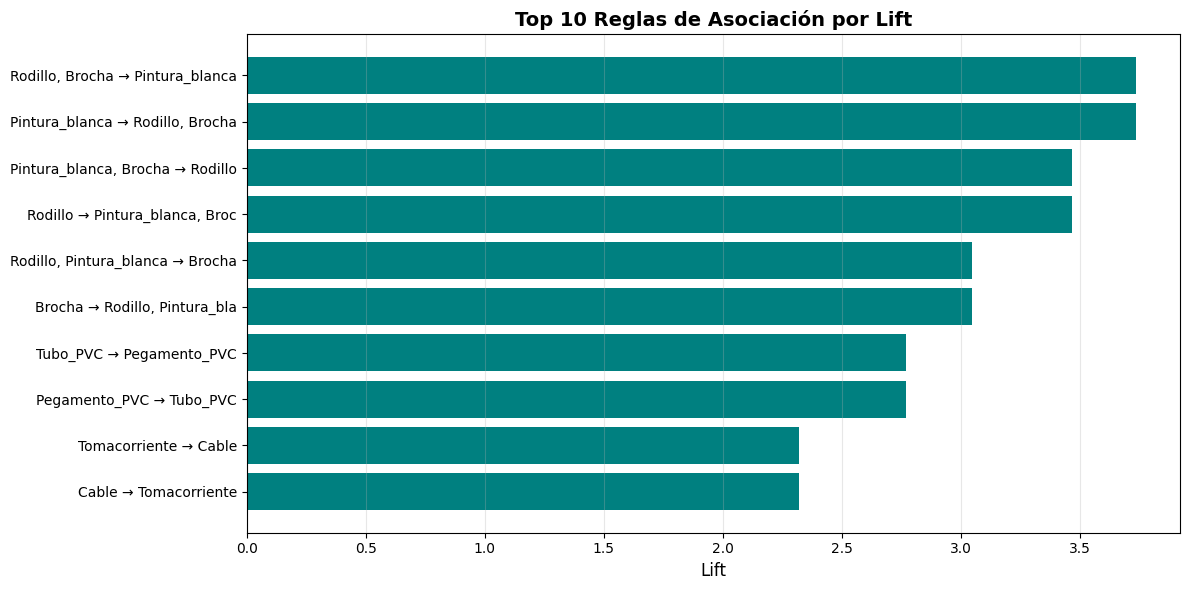

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [29]:
# GRÁFICO 3: Top reglas para presentación
plt.figure(figsize=(12, 6))
top_lift = reglas_ordenadas.head(10)
productos_str = [f"{', '.join(list(a))[:30]} → {', '.join(list(c))[:20]}"
                 for a, c in zip(top_lift['antecedents'], top_lift['consequents'])]
plt.barh(range(len(productos_str)), top_lift['lift'].values, color='teal')
plt.yticks(range(len(productos_str)), productos_str)
plt.xlabel('Lift', fontsize=12)
plt.title('Top 10 Reglas de Asociación por Lift', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('top_reglas_lift.png', dpi=100)
plt.show()